In [2]:
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
df=sns.load_dataset('iris')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# As we can see, there are 3 classes in the dataset. We will remove one of the classes to make it a binary classification problem. as  SVM is a binary classifier, it can only classify between two classes. So we will remove the class 'setosa' from the dataset.
df=df[df['species']!='setosa']

In [6]:
df['species'].unique()

array(['versicolor', 'virginica'], dtype=object)

In [7]:
df['species'].unique()

array(['versicolor', 'virginica'], dtype=object)

In [8]:
df['species']=df['species'].map({"versicolor":0,"virginica":1})


In [9]:
## Features into independent and dependent features
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [10]:
X

,sepal_length,sepal_width,petal_length,petal_width
50,7.0,3.2,4.7,1.4
51,6.4,3.2,4.5,1.5
52,6.9,3.1,4.9,1.5
53,5.5,2.3,4.0,1.3
54,6.5,2.8,4.6,1.5
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
y

50     0
51     0
52     0
53     0
54     0
      ..
145    1
146    1
147    1
148    1
149    1
Name: species, Length: 100, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [13]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
105,7.6,3.0,6.6,2.1
138,6.0,3.0,4.8,1.8
76,6.8,2.8,4.8,1.4
92,5.8,2.6,4.0,1.2
119,6.0,2.2,5.0,1.5
...,...,...,...,...
110,6.5,3.2,5.1,2.0
121,5.6,2.8,4.9,2.0
64,5.6,2.9,3.6,1.3
142,5.8,2.7,5.1,1.9


In [26]:
from sklearn.linear_model import LogisticRegression
regression = LogisticRegression(solver='saga', max_iter=5000)

In [28]:
from sklearn.model_selection import GridSearchCV

parameter = [
    {
        'penalty':['l1','l2'],
        'C':[0.5,1,2,3,5,6,7,9,10,30,45]
    },
    {
        'penalty':['elasticnet'],
        'C':[0.5,1,2,3,5,6,7,9,10,30,45],
        'l1_ratio':[0.1,0.5,0.9]
    }
]

log_regressor = GridSearchCV(
    regression,
    parameter,
    scoring='accuracy',
    cv=5
)

log_regressor.fit(X,y)



,estimator,LogisticRegre...solver='saga')
,param_grid,"[{'C': [0.5, 1, ...], 'penalty': ['l1', 'l2']}, {'C': [0.5, 1, ...], 'l1_ratio': [0.1, 0.5, ...], 'penalty': ['elasticnet']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [29]:
print(log_regressor.best_params_)

{'C': 2, 'penalty': 'l2'}


In [30]:
print(log_regressor.best_score_)

0.9800000000000001


In [31]:
prediction_log=log_regressor.predict(X_test)

In [32]:
df.corr()

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,0.553855,0.828479,0.593709,0.494305
sepal_width,0.553855,1.000000,0.519802,0.566203,0.308080
petal_length,0.828479,0.519802,1.000000,0.823348,0.786424
petal_width,0.593709,0.566203,0.823348,1.000000,0.828129
species,0.494305,0.308080,0.786424,0.828129,1.000000


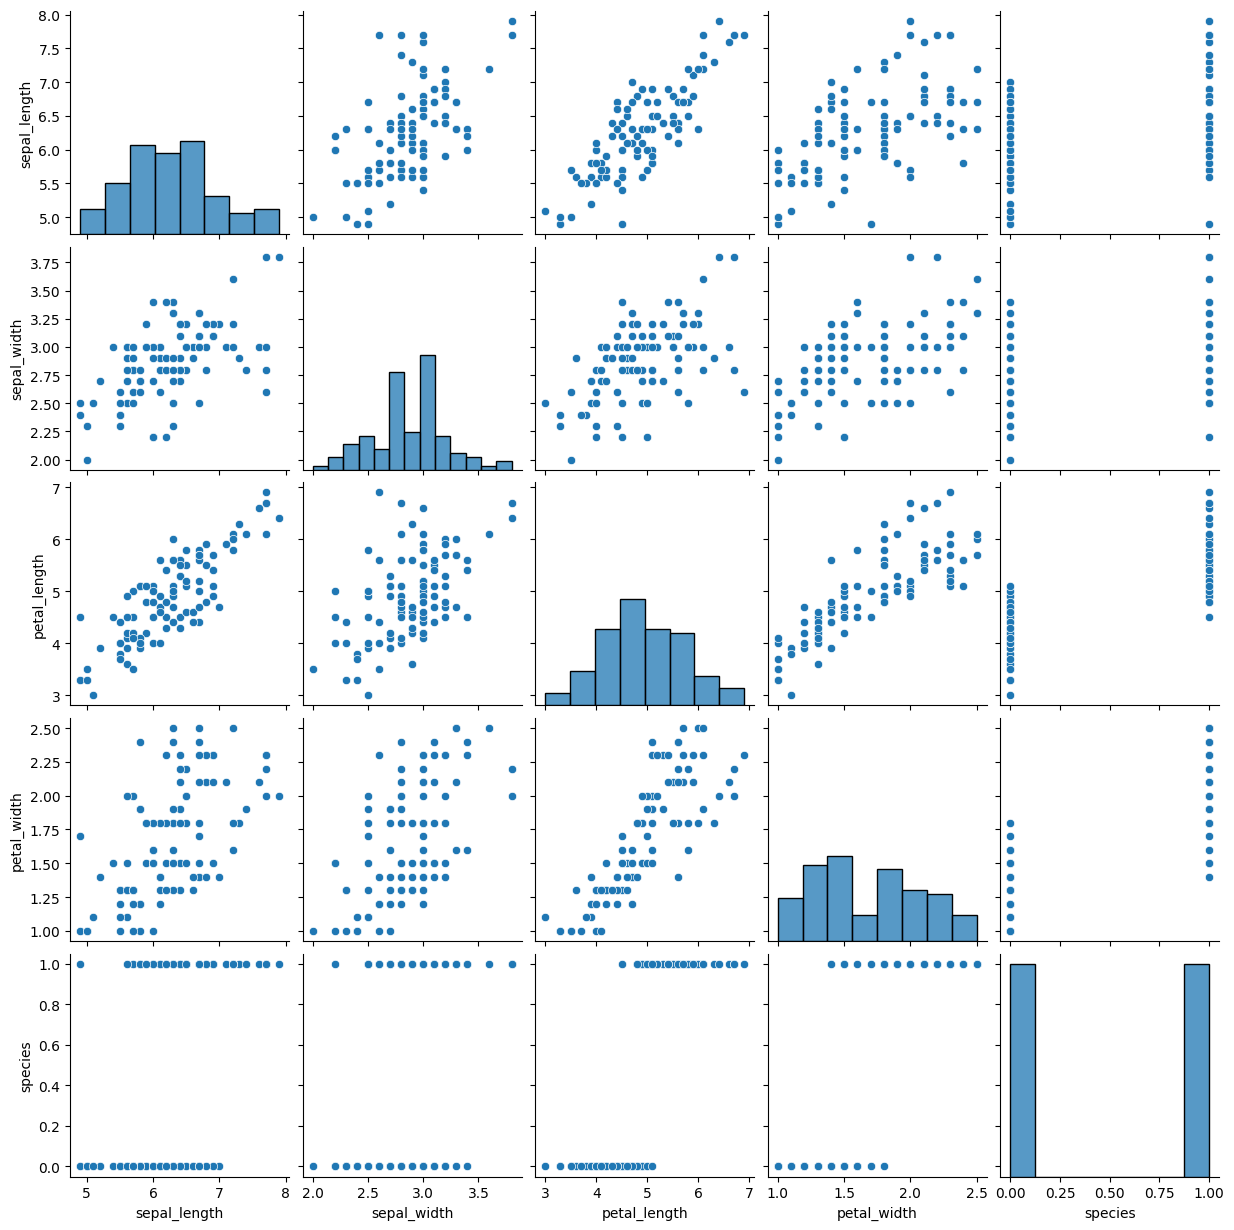

In [37]:
sns.pairplot(df)

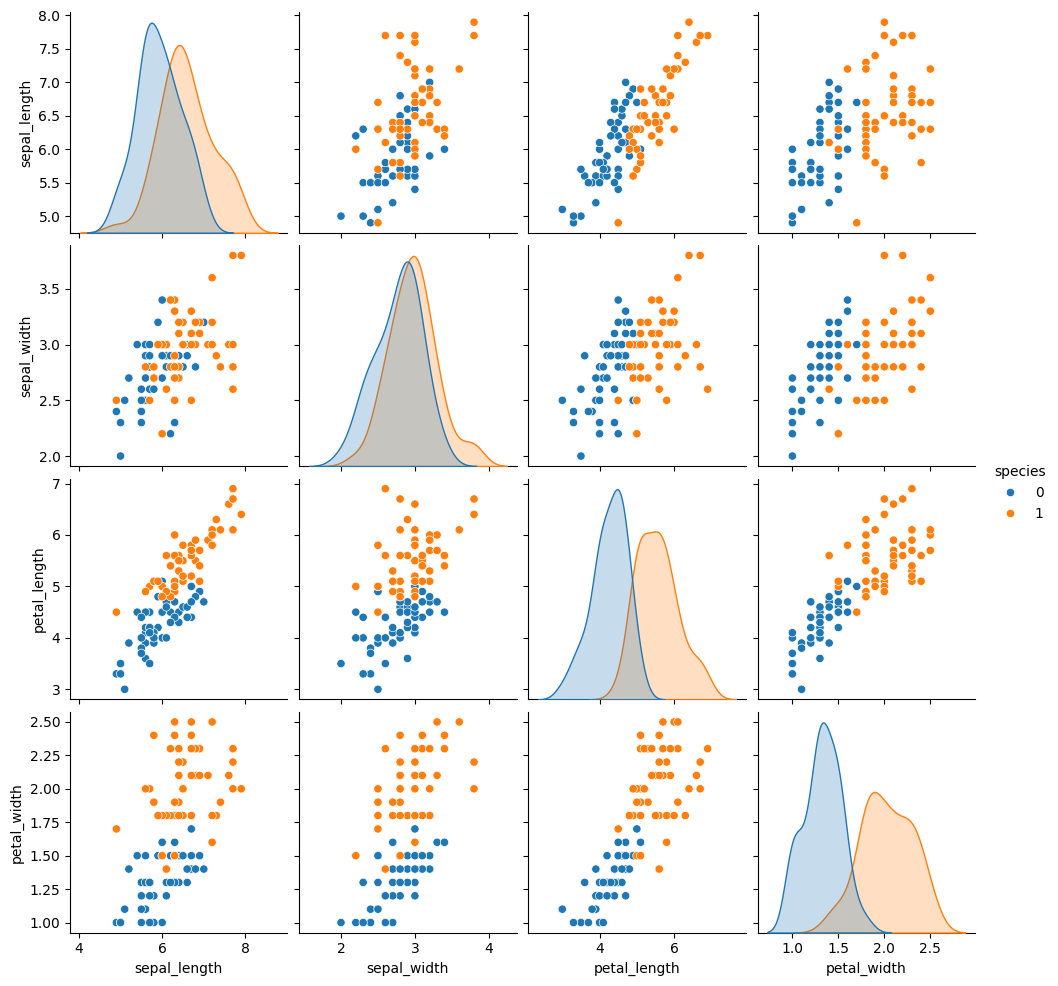

In [ ]:
sns.pairplot(df,hue='species')

In [46]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    precision_score
)

In [47]:
confusion_matrix(y_test,prediction_log)

array([[11,  1],
       [ 0,  8]])

In [48]:
f1_score(y_test,prediction_log)

0.9411764705882353

In [49]:
# Predictions
prediction_log = log_regressor.predict(X_test)

In [50]:
# Probability predictions
y_prob = log_regressor.predict_proba(X_test)[:,1]

In [51]:
# =========================
# Accuracy
# =========================
accuracy = accuracy_score(y_test, prediction_log)
print("Accuracy Score:")
print(accuracy)

Accuracy Score:
0.95


In [52]:
# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, prediction_log)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[11  1]
 [ 0  8]]


In [55]:
# =========================
# Precision
# =========================
precision = precision_score(y_test, prediction_log)
print("\nPrecision Score:")
print(precision)


Precision Score:
0.8888888888888888


In [56]:
# =========================
# Recall
# =========================
recall = recall_score(y_test, prediction_log)
print("\nRecall Score:")
print(recall)


Recall Score:
1.0


In [57]:
# =========================
# F1 Score
# =========================
f1 = f1_score(y_test, prediction_log)
print("\nF1 Score:")
print(f1)


F1 Score:
0.9411764705882353


In [58]:
# =========================
# ROC AUC Score
# =========================
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC AUC Score:")
print(roc_auc)


# =========================
# Classification Report
# =========================
report = classification_report(y_test, prediction_log)
print("\nClassification Report:")
print(report)


# =========================
# ROC Curve Values
# =========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print("\nROC Curve:")
print("False Positive Rate:", fpr)
print("True Positive Rate:", tpr)
print("Thresholds:", thresholds)


# =========================
# Precision Recall Curve
# =========================
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_prob)

print("\nPrecision Recall Curve:")
print("Precision:", precision_curve)
print("Recall:", recall_curve)
print("Thresholds:", thresholds_pr)


ROC AUC Score:
0.9583333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.89      1.00      0.94         8

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20


ROC Curve:
False Positive Rate: [0.         0.         0.         0.08333333 0.08333333 1.        ]
True Positive Rate: [0.    0.125 0.5   0.5   1.    1.   ]
Thresholds: [       inf 0.97867463 0.93194759 0.7212223  0.53803838 0.01027851]

Precision Recall Curve:
Precision: [0.4        0.42105263 0.44444444 0.47058824 0.5        0.53333333
 0.57142857 0.61538462 0.66666667 0.72727273 0.8        0.88888889
 0.875      0.85714286 0.83333333 0.8        1.         1.
 1.         1.         1.        ]
Recall: [1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 0.875 0.75  0.625 0.5   0.5   0.